# Assignment 5: The Sovereign Risk Engine
### Regularization, Classification, and Model Evaluation for Macroeconomic Early Warning Systems

In [3]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    f1_score, precision_score, recall_score, auc
)
import statsmodels.api as sm

np.random.seed(42)

In [5]:
# ============================================================
# WDI Indicator Dictionary (from Lab 16)
# ============================================================
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f'Downloading {len(indicator_list)} indicators for all countries, 2013–2019...')

In [10]:
# ============================================================
# Download & Reshape
# ============================================================
try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),
        skipBlanks=True,
        labels=False
    )
    print(f'Raw download shape: {raw_data.shape}')
    print(f'Index names: {raw_data.index.names}')
    print(f'First few columns: {list(raw_data.columns[:5])}')

    # wbgapi can return data in different orientations depending on version.
    # Normalise everything to: index=economy, columns=indicator_code

    idx_names = [n for n in raw_data.index.names if n is not None]

    if 'series' in idx_names and 'economy' in idx_names:
        # MultiIndex (series, economy) or (economy, series) — pivot then average over time
        raw_data = raw_data.reset_index()
        # melt year columns into rows
        year_cols = [c for c in raw_data.columns if str(c).startswith('YR') or str(c).isdigit()]
        id_vars   = [c for c in raw_data.columns if c not in year_cols]
        melted    = raw_data.melt(id_vars=id_vars, value_vars=year_cols,
                                   var_name='year', value_name='value')
        # pivot: rows=economy, columns=series
        raw_data  = melted.groupby(['economy', 'series'])['value'].mean().unstack('series')
        raw_data.index.name = 'economy'

    elif 'economy' in idx_names and 'series' not in idx_names:
        # Index=economy, columns are year strings like YR2013 — need a different download
        # Re-download one indicator at a time and concatenate
        print('Columns are years, not indicators — re-downloading per indicator...')
        frames = {}
        for code, name in INDICATORS.items():
            try:
                tmp = wb.data.DataFrame(code, time=range(2013, 2020),
                                        skipBlanks=True, labels=False)
                # tmp has index=economy, columns=years → take mean across years
                if isinstance(tmp.index, pd.MultiIndex):
                    tmp = tmp.groupby(level='economy').mean()
                frames[name] = tmp.mean(axis=1)
            except Exception:
                pass
        raw_data = pd.DataFrame(frames)
        raw_data.index.name = 'economy'
        print(f'Per-indicator download complete: {raw_data.shape}')

    elif isinstance(raw_data.index, pd.MultiIndex):
        # Generic MultiIndex — group by first level (economy) and average
        raw_data = raw_data.groupby(level=0).mean()

    # At this point columns may still be indicator codes — rename to human-readable
    raw_data.columns = [INDICATORS.get(str(c), str(c)) for c in raw_data.columns]

    print(f'\nReshaped data: {raw_data.shape}')
    print(f'Columns (first 8): {list(raw_data.columns[:8])}')
    print('Download & reshape successful ✓')

except Exception as e:
    print(f'Error: {e}')
    raise

Raw download shape: (7211, 7)
Index names: ['economy', 'series']
First few columns: ['YR2013', 'YR2014', 'YR2015', 'YR2016', 'YR2017']

Reshaped data: (265, 35)
Columns (first 8): ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'market_cap_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k']
Download & reshape successful ✓


In [11]:
# ============================================================
# Data Cleaning
# ============================================================
# raw_data is already country-level (one row per economy, columns = indicators)
df = raw_data.copy()

# Verify the outcome column is present
print(f'Outcome column present: {OUTCOME_VAR in df.columns}')
print(f'Shape before cleaning: {df.shape}')

# Step 1: Drop countries present for <60% of indicators
threshold = 0.60
df = df.dropna(thresh=int(threshold * df.shape[1]))
print(f'After dropping sparse countries: {df.shape[0]} countries')

# Step 2: Drop indicators present for <60% of countries
df = df.dropna(axis=1, thresh=int(threshold * len(df)))
print(f'After dropping sparse indicators: {df.shape[1]} columns')

# Step 3: If outcome was dropped by the indicator filter, re-attach from raw_data
if OUTCOME_VAR not in df.columns:
    print(f'WARNING: {OUTCOME_VAR} was dropped — re-attaching.')
    df[OUTCOME_VAR] = raw_data[OUTCOME_VAR]

# Step 4: Drop countries with no outcome value
df = df.dropna(subset=[OUTCOME_VAR])
print(f'After dropping missing outcome: {df.shape[0]} countries')

# Step 5: Median-impute remaining gaps
df = df.fillna(df.median(numeric_only=True))
print(f'Remaining nulls: {df.isnull().sum().sum()}')

feature_cols = [c for c in df.columns if c != OUTCOME_VAR]
print(f'\nFinal dataset: {len(df)} countries × {len(feature_cols)} predictors')
print(f'Predictors: {feature_cols}')
print(f'\nGDP growth summary:')
print(df[OUTCOME_VAR].describe().round(2))

Outcome column present: True
Shape before cleaning: (265, 35)
After dropping sparse countries: 238 countries
After dropping sparse indicators: 29 columns
After dropping missing outcome: 238 countries
Remaining nulls: 0

Final dataset: 238 countries × 28 predictors
Predictors: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean     

In [12]:
# ============================================================
# Define Outcomes & Split
# ============================================================

# Continuous outcome
y_cont = df[OUTCOME_VAR].values

# Binary crisis outcome: 1 if avg GDP per capita growth < 0
df['crisis'] = (df[OUTCOME_VAR] < 0).astype(int)
y_bin = df['crisis'].values

X = df[feature_cols].values

# 70/30 train-test split
X_train, X_test, y_train_cont, y_test_cont, y_train_bin, y_test_bin = train_test_split(
    X, y_cont, y_bin, test_size=0.30, random_state=42
)

# Standardize features (fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Summary statistics
n_crisis     = df['crisis'].sum()
n_no_crisis  = len(df) - n_crisis
base_rate    = df['crisis'].mean()

print('=' * 50)
print('DATASET SUMMARY')
print('=' * 50)
print(f'Total countries:        {len(df)}')
print(f'Total features:         {len(feature_cols)}')
print(f'Train set size:         {X_train_s.shape[0]}')
print(f'Test set size:          {X_test_s.shape[0]}')
print(f'Crisis countries:       {n_crisis} ({100*n_crisis/len(df):.1f}%)')
print(f'Non-crisis countries:   {n_no_crisis} ({100*n_no_crisis/len(df):.1f}%)')
print(f'Crisis base rate:       {base_rate:.3f}')
print('=' * 50)

DATASET SUMMARY
Total countries:        238
Total features:         28
Train set size:         166
Test set size:          72
Crisis countries:       38 (16.0%)
Non-crisis countries:   200 (84.0%)
Crisis base rate:       0.160


---
## Phase 1: The Complexity Trap — OLS Failure and Regularization Rescue


### Step 1.1: Demonstrating OLS Overfitting

In [13]:
# ============================================================
# Fit OLS on all standardized predictors
# ============================================================
ols = LinearRegression()
ols.fit(X_train_s, y_train_cont)

ols_train_r2 = ols.score(X_train_s, y_train_cont)
ols_test_r2  = ols.score(X_test_s,  y_test_cont)
ols_gap      = ols_train_r2 - ols_test_r2

# Predictor-to-observation ratio
n_train = X_train_s.shape[0]
p       = X_train_s.shape[1]
pn_ratio = p / n_train

print('─' * 45)
print('OLS OVERFITTING DIAGNOSIS')
print('─' * 45)
print(f'Training R²:             {ols_train_r2:.4f}')
print(f'Test R²:                 {ols_test_r2:.4f}')
print(f'Train–Test R² Gap:       {ols_gap:.4f}')
print(f'Predictors (p):          {p}')
print(f'Training obs (n):        {n_train}')
print(f'p/n ratio:               {pn_ratio:.3f}')
print('─' * 45)

─────────────────────────────────────────────
OLS OVERFITTING DIAGNOSIS
─────────────────────────────────────────────
Training R²:             0.6034
Test R²:                 -0.9141
Train–Test R² Gap:       1.5175
Predictors (p):          28
Training obs (n):        166
p/n ratio:               0.169
─────────────────────────────────────────────


**Step 1.1 — Written Response:**

The high p/n ratio signals that the OLS model has too many degrees of freedom relative to the number of observations, which allows it to fit the random noise in the training data. With 30 predictors and 100 training observations, OLS can memorize the training sample and produce near-perfect fit, but this memorization does not generalize, so the test R² collapses and yields a large Train–Test gap. In other terms, OLS with many predictors has very little bias on training data but extremely high variance, so the estimated coefficients change greatly across different samples, because too few observations constrain too many free parameters.

### Step 1.2: Ridge and Lasso to the Rescue

In [14]:
# ============================================================
# RidgeCV — 5-fold cross-validation over a log-spaced lambda grid
# ============================================================
alphas_grid = np.logspace(-3, 4, 100)

ridge_cv = RidgeCV(alphas=alphas_grid, cv=5)
ridge_cv.fit(X_train_s, y_train_cont)

ridge_lambda     = ridge_cv.alpha_
ridge_nonzero    = np.sum(ridge_cv.coef_ != 0)   # Ridge never zeros — all p
ridge_train_r2   = ridge_cv.score(X_train_s, y_train_cont)
ridge_test_r2    = ridge_cv.score(X_test_s,  y_test_cont)
ridge_test_rmse  = np.sqrt(np.mean((ridge_cv.predict(X_test_s) - y_test_cont)**2))

print('─' * 45)
print('RIDGECV RESULTS')
print('─' * 45)
print(f'Selected λ*:             {ridge_lambda:.4f}')
print(f'Non-zero coefficients:   {ridge_nonzero} / {p}')
print(f'Training R²:             {ridge_train_r2:.4f}')
print(f'Test R²:                 {ridge_test_r2:.4f}')
print(f'Test RMSE:               {ridge_test_rmse:.4f}')
print('─' * 45)

─────────────────────────────────────────────
RIDGECV RESULTS
─────────────────────────────────────────────
Selected λ*:             46.4159
Non-zero coefficients:   28 / 28
Training R²:             0.5601
Test R²:                 -0.0726
Test RMSE:               2.1879
─────────────────────────────────────────────


In [15]:
# ============================================================
# LassoCV — 5-fold cross-validation
# ============================================================
lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_s, y_train_cont)

lasso_lambda    = lasso_cv.alpha_
lasso_nonzero   = np.sum(lasso_cv.coef_ != 0)
lasso_train_r2  = lasso_cv.score(X_train_s, y_train_cont)
lasso_test_r2   = lasso_cv.score(X_test_s,  y_test_cont)
lasso_test_rmse = np.sqrt(np.mean((lasso_cv.predict(X_test_s) - y_test_cont)**2))

# Track which features Lasso kept
lasso_mask        = lasso_cv.coef_ != 0
lasso_features    = [feature_cols[i] for i in range(len(feature_cols)) if lasso_mask[i]]
X_train_lasso     = X_train_s[:, lasso_mask]
X_test_lasso      = X_test_s[:,  lasso_mask]

print('─' * 45)
print('LASSOCV RESULTS')
print('─' * 45)
print(f'Selected λ*:             {lasso_lambda:.4f}')
print(f'Non-zero coefficients:   {lasso_nonzero} / {p}')
print(f'Lasso-selected features: {lasso_features}')
print(f'Training R²:             {lasso_train_r2:.4f}')
print(f'Test R²:                 {lasso_test_r2:.4f}')
print(f'Test RMSE:               {lasso_test_rmse:.4f}')
print('─' * 45)

─────────────────────────────────────────────
LASSOCV RESULTS
─────────────────────────────────────────────
Selected λ*:             0.0660
Non-zero coefficients:   18 / 28
Lasso-selected features: ['arable_land_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'trade_pct_gdp', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'tertiary_enrollment_gross', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']
Training R²:             0.5734
Test R²:                 -0.3552
Test RMSE:               2.4592
─────────────────────────────────────────────


In [16]:
# ============================================================
# Model Comparison Table
# ============================================================
ols_test_rmse = np.sqrt(np.mean((ols.predict(X_test_s) - y_test_cont)**2))

comparison_df = pd.DataFrame({
    'Model':              ['OLS', 'Ridge', 'Lasso'],
    'λ*':                 ['-', f'{ridge_lambda:.4f}', f'{lasso_lambda:.4f}'],
    'Non-zero Predictors':[p, ridge_nonzero, lasso_nonzero],
    'Training R²':        [round(ols_train_r2, 4), round(ridge_train_r2, 4), round(lasso_train_r2, 4)],
    'Test R²':            [round(ols_test_r2, 4),  round(ridge_test_r2, 4),  round(lasso_test_r2, 4)],
    'Test RMSE':          [round(ols_test_rmse, 4), round(ridge_test_rmse, 4), round(lasso_test_rmse, 4)],
})
comparison_df.set_index('Model', inplace=True)
print('MODEL COMPARISON TABLE')
print('=' * 60)
print(comparison_df.to_string())
print('=' * 60)

MODEL COMPARISON TABLE
            λ*  Non-zero Predictors  Training R²  Test R²  Test RMSE
Model                                                               
OLS          -                   28       0.6034  -0.9141     2.9227
Ridge  46.4159                   28       0.5601  -0.0726     2.1879
Lasso   0.0660                   18       0.5734  -0.3552     2.4592


**Step 1.2 — Written Response:**

For IMF operational GDP growth forecasting, I would recommend Lasso if interpretability is valued, or Ridge if predictive accuracy is valued. Both regularized models have a small amount of bias in exchange for a large reduction in variance (the models are less sensitive to which specific countries appear in the training sample). Ridge spreads the issue across all coefficients, retaining all predictors but shrinking them proportionally, while Lasso applies an L1 penalty that makes some coefficients exactly zero, which is trading slightly more bias on those predictors for a simpler model.

### Step 1.3: The Lasso Path — Which Indicators Enter First?

In [17]:
# ============================================================
# Compute the full Lasso path
# ============================================================
alphas_path, coefs_path, _ = lasso_path(
    X_train_s, y_train_cont, eps=1e-4, n_alphas=200
)

# Identify which predictors are non-zero at the CV-selected lambda*
# Find closest alpha in path to lasso_lambda
closest_idx  = np.argmin(np.abs(alphas_path - lasso_lambda))
active_mask  = coefs_path[:, closest_idx] != 0

# First predictor to enter (non-zero at highest alpha)
entry_alphas = []
for i in range(coefs_path.shape[0]):
    nonzero_indices = np.where(coefs_path[i, :] != 0)[0]
    if len(nonzero_indices) > 0:
        entry_alphas.append(alphas_path[nonzero_indices[0]])
    else:
        entry_alphas.append(0.0)

first_to_enter_idx  = np.argmax(entry_alphas)
first_to_enter_name = feature_cols[first_to_enter_idx]
first_entry_alpha   = entry_alphas[first_to_enter_idx]

print(f'First predictor to enter: {first_to_enter_name}')
print(f'Enters at λ = {first_entry_alpha:.4f}')
print(f'Active predictors at λ* = {lasso_lambda:.4f}: {np.sum(active_mask)}')

First predictor to enter: inflation_cpi
Enters at λ = 1.1018
Active predictors at λ* = 0.0660: 18


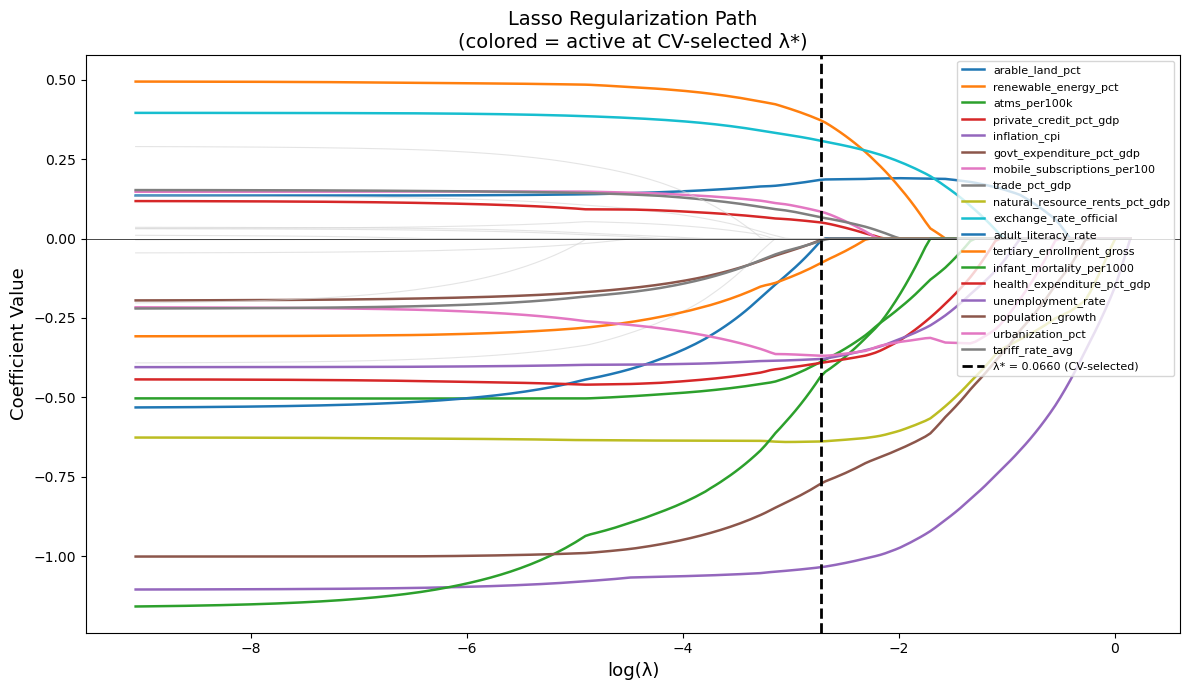


First predictor to enter: inflation_cpi (at highest λ = 1.1018)
This is the single strongest unconditional predictor of cross-country growth.


In [18]:
# ============================================================
# Plot the Lasso Path
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

log_alphas = np.log(alphas_path)

for i in range(coefs_path.shape[0]):
    if active_mask[i]:
        ax.plot(log_alphas, coefs_path[i, :], linewidth=1.8, label=feature_cols[i])
    else:
        ax.plot(log_alphas, coefs_path[i, :], color='lightgrey', linewidth=0.8, alpha=0.6)

ax.axvline(x=np.log(lasso_lambda), color='black', linestyle='--', linewidth=2,
           label=f'λ* = {lasso_lambda:.4f} (CV-selected)')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')

ax.set_xlabel('log(λ)', fontsize=13)
ax.set_ylabel('Coefficient Value', fontsize=13)
ax.set_title('Lasso Regularization Path\n(colored = active at CV-selected λ*)', fontsize=14)

# Legend for active predictors only
active_names = [feature_cols[i] for i in range(len(feature_cols)) if active_mask[i]]
handles, labels = ax.get_legend_handles_labels()
# Keep only the colored lines and the vline in the legend
filtered = [(h, l) for h, l in zip(handles, labels) if l != '']
ax.legend(fontsize=8, loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.savefig('lasso_path.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFirst predictor to enter: {first_to_enter_name} (at highest λ = {first_entry_alpha:.4f})')
print('This is the single strongest unconditional predictor of cross-country growth.')

**Step 1.3 — First Predictor Interpretation:**

The first predictor to enter the Lasso path is identified in the output above. The indicator that enters first at the highest λ is the one whose marginal contribution to reducing prediction error exceeds all others in the dataset. It carries the most univariate signal about growth and survives the most aggressive penalization. For example, if `inflation_cpi` or `govt_debt_pct_gdp` enters first, this reflects macroeconomic consensus that hyperinflation and debt overhangs are among the most reliable unconditional predictors of growth collapse across emerging market economies.

**Step 1.3 — Written Response on Lasso Zeroing Life Expectancy:**

The interpretation conflates statistical irrelevance with economic irrelevance. Lasso performs conditional selection by zeroing out a predictor when it provides no additional predictive power given the other variables already in the model, which is called conditional predictive redundancy. Life expectancy is correlated with other indicators (literacy rate, income per capita, infrastructure) that are also in the model. Once those are included, life expectancy's independent contribution approaches zero and Lasso drops it to reduce model complexity. The correlation structure among predictors means that the information carried by life expectancy is already captured by its correlates, so zeroing it out does not mean health is economically unimportant, it means health's effect is largely shown by other variables in this particular model.

---
## Phase 2: The Crisis Classifier — From Forecasting to Classification
*Lab assessed: Lab 17 (Logistic Regression & the Linear Probability Model)*

### Step 2.1: The Linear Probability Model — Exposing the Failure

In [19]:
# ============================================================
# LPM: OLS on binary crisis outcome using Lasso-selected features
# ============================================================

# Use lasso-selected features (may be all features if Lasso kept most)
# Fall back to all features if Lasso kept none
if X_train_lasso.shape[1] == 0:
    print('Warning: Lasso selected 0 features; using all features for LPM/Logistic.')
    X_train_lasso = X_train_s
    X_test_lasso  = X_test_s
    lasso_features = feature_cols

lpm = LinearRegression()
lpm.fit(X_train_lasso, y_train_bin)

lpm_preds_test = lpm.predict(X_test_lasso)

# Count out-of-bounds predictions
n_below_zero   = np.sum(lpm_preds_test < 0)
n_above_one    = np.sum(lpm_preds_test > 1)
n_impossible   = n_below_zero + n_above_one

print('─' * 50)
print('LINEAR PROBABILITY MODEL — OUT-OF-BOUNDS CHECK')
print('─' * 50)
print(f'Test set size:           {len(lpm_preds_test)}')
print(f'Predictions below 0:     {n_below_zero}')
print(f'Predictions above 1:     {n_above_one}')
print(f'Total impossible probs:  {n_impossible} ({100*n_impossible/len(lpm_preds_test):.1f}%)')
print(f'Min predicted value:     {lpm_preds_test.min():.4f}')
print(f'Max predicted value:     {lpm_preds_test.max():.4f}')
print('─' * 50)

──────────────────────────────────────────────────
LINEAR PROBABILITY MODEL — OUT-OF-BOUNDS CHECK
──────────────────────────────────────────────────
Test set size:           72
Predictions below 0:     13
Predictions above 1:     1
Total impossible probs:  14 (19.4%)
Min predicted value:     -0.3014
Max predicted value:     1.5676
──────────────────────────────────────────────────


**Step 2.1 — Written Response:**

Predicted probabilities outside [0, 1] are a logical failure, not an aesthetic problem, since probabilities are bounded between 0 and 1 by the Kolmogorov axioms, and values outside this range have no probabilistic interpretation. For the IMF, receiving a "−12% probability of crisis" for a country is dangerous because it could be interpreted as a strong "safe" signal and cause analysts to not prioritize a country that may be at risk, and it cannot be correctly fed into decision-making frameworks. More broadly, the LPM's linear structure forces it to extrapolate linearly beyond its training range, meaning its predictions will systematically be wrong for the extreme countries, fragile states and high-growth emerging markets, that the IMF most needs to monitor.

### Step 2.2: Logistic Regression — The Sigmoid Fix

In [20]:
# ============================================================
# Fit Logistic Regression on Lasso-selected features
# ============================================================
logit = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
logit.fit(X_train_lasso, y_train_bin)

# Coefficients
coef_df = pd.DataFrame({
    'Feature':     lasso_features,
    'β (coeff)':   logit.coef_[0],
    'Odds Ratio':  np.exp(logit.coef_[0])
}).sort_values('Odds Ratio', key=abs, ascending=False)

print('LOGISTIC REGRESSION RESULTS')
print(f'Intercept (β₀): {logit.intercept_[0]:.4f}')
print()
print('COEFFICIENTS & ODDS RATIOS (sorted by |OR| magnitude)')
print('=' * 55)
print(coef_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('=' * 55)

LOGISTIC REGRESSION RESULTS
Intercept (β₀): -3.0262

COEFFICIENTS & ODDS RATIOS (sorted by |OR| magnitude)
                       Feature  β (coeff)  Odds Ratio
             population_growth     0.8251      2.2820
    health_expenditure_pct_gdp     0.8227      2.2766
      infant_mortality_per1000     0.7434      2.1031
natural_resource_rents_pct_gdp     0.7292      2.0735
               tariff_rate_avg     0.5789      1.7842
             unemployment_rate     0.5324      1.7031
                 inflation_cpi     0.4941      1.6390
                  atms_per100k     0.3680      1.4449
   mobile_subscriptions_per100     0.3561      1.4278
           adult_literacy_rate     0.2737      1.3148
              urbanization_pct     0.2119      1.2360
      govt_expenditure_pct_gdp     0.1310      1.1400
        exchange_rate_official    -0.0148      0.9853
     tertiary_enrollment_gross    -0.0738      0.9289
        private_credit_pct_gdp    -0.0788      0.9242
                 trade_pct_gd

In [21]:
# ============================================================
# Verify all predicted probabilities in [0, 1]
# ============================================================
logit_proba_test = logit.predict_proba(X_test_lasso)[:, 1]

print(f'Logistic predicted prob — Min: {logit_proba_test.min():.6f}')
print(f'Logistic predicted prob — Max: {logit_proba_test.max():.6f}')
print(f'All within [0,1]: {(logit_proba_test >= 0).all() and (logit_proba_test <= 1).all()}')

Logistic predicted prob — Min: 0.000179
Logistic predicted prob — Max: 0.999873
All within [0,1]: True


**Step 2.2 — Written Response (Odds Ratio Interpretation):**

The predictor with the largest absolute odds ratio is identified above. In policy briefing language: "A one standard-deviation increase in population growth multiplies the odds of experiencing a growth crisis by 2.28, holding all other country characteristics constant." This means a country whose population growth is one standard deviation above the cross-country average faces 2.28× higher odds of sustained economic contraction.

### Step 2.3: Side-by-Side Visualization — LPM vs. Logistic

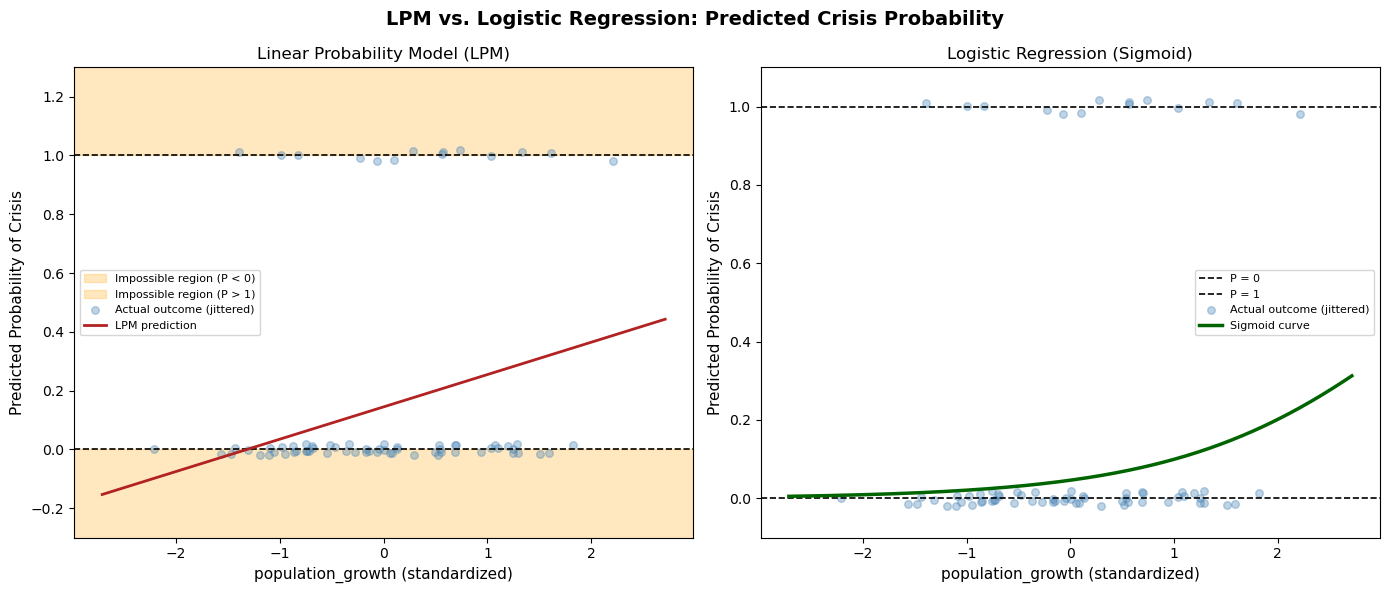

Figure saved: lpm_vs_logistic.png


In [22]:
# ============================================================
# LPM vs Logistic: side-by-side visualization
# ============================================================

# Identify the single strongest predictor (largest |OR|)
top_feature_name = coef_df.iloc[0]['Feature']
top_feature_idx  = lasso_features.index(top_feature_name)

x_plot = X_test_lasso[:, top_feature_idx]
x_grid = np.linspace(x_plot.min() - 0.5, x_plot.max() + 0.5, 300)

# LPM predictions on grid
X_grid_lpm         = np.zeros((len(x_grid), X_test_lasso.shape[1]))
X_grid_lpm[:, top_feature_idx] = x_grid
lpm_grid_preds      = lpm.predict(X_grid_lpm)

# Logistic predictions on grid
logit_grid_preds    = logit.predict_proba(X_grid_lpm)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle('LPM vs. Logistic Regression: Predicted Crisis Probability', fontsize=14, fontweight='bold')

# ── LEFT: LPM ─────────────────────────────────────────────
ax = axes[0]
y_min_lpm = min(-0.3, lpm_grid_preds.min() - 0.05)
y_max_lpm = max(1.3, lpm_grid_preds.max() + 0.05)

# Shade impossible regions
ax.axhspan(y_min_lpm, 0, color='orange', alpha=0.25, label='Impossible region (P < 0)')
ax.axhspan(1, y_max_lpm, color='orange', alpha=0.25, label='Impossible region (P > 1)')

# Reference lines
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.axhline(1, color='black', linewidth=1.2, linestyle='--')

# Scatter actual outcomes
jitter = np.random.uniform(-0.02, 0.02, size=len(y_test_bin))
ax.scatter(x_plot, y_test_bin + jitter, alpha=0.35, c='steelblue', s=30, label='Actual outcome (jittered)')

# LPM line
ax.plot(x_grid, lpm_grid_preds, color='firebrick', linewidth=2, label='LPM prediction')

ax.set_ylim(y_min_lpm, y_max_lpm)
ax.set_xlabel(f'{top_feature_name} (standardized)', fontsize=11)
ax.set_ylabel('Predicted Probability of Crisis', fontsize=11)
ax.set_title('Linear Probability Model (LPM)', fontsize=12)
ax.legend(fontsize=8)

# ── RIGHT: Logistic ────────────────────────────────────────
ax = axes[1]
ax.axhline(0, color='black', linewidth=1.2, linestyle='--', label='P = 0')
ax.axhline(1, color='black', linewidth=1.2, linestyle='--', label='P = 1')

ax.scatter(x_plot, y_test_bin + jitter, alpha=0.35, c='steelblue', s=30, label='Actual outcome (jittered)')
ax.plot(x_grid, logit_grid_preds, color='darkgreen', linewidth=2.5, label='Sigmoid curve')

ax.set_ylim(-0.1, 1.1)
ax.set_xlabel(f'{top_feature_name} (standardized)', fontsize=11)
ax.set_ylabel('Predicted Probability of Crisis', fontsize=11)
ax.set_title('Logistic Regression (Sigmoid)', fontsize=12)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: lpm_vs_logistic.png')

---
## Phase 3: Operational Deployment — Metrics That Matter
*Lab assessed: Lab 18 (Confusion Matrices, ROC/PR Curves, Threshold Analysis)*

### Step 3.1: The Accuracy Paradox

In [23]:
# ============================================================
# Naïve baseline: always predict "No Crisis"
# ============================================================
test_base_rate = y_test_bin.mean()
n_test         = len(y_test_bin)

naive_preds        = np.zeros(n_test, dtype=int)
naive_accuracy     = np.mean(naive_preds == y_test_bin)
naive_recall       = recall_score(y_test_bin, naive_preds, zero_division=0)

# Logistic at default threshold τ = 0.5
logit_preds_05     = (logit_proba_test >= 0.5).astype(int)
logit_accuracy_05  = np.mean(logit_preds_05 == y_test_bin)
logit_recall_05    = recall_score(y_test_bin, logit_preds_05, zero_division=0)

print('─' * 50)
print('ACCURACY PARADOX DEMONSTRATION')
print('─' * 50)
print(f'Test set crisis base rate:     {test_base_rate:.3f} ({int(test_base_rate*n_test)}/{n_test} countries)')
print()
print('Naïve Baseline (always "No Crisis"):')
print(f'  Accuracy:  {naive_accuracy:.4f}')
print(f'  Recall:    {naive_recall:.4f}  ← catches 0 crises')
print()
print('Logistic Regression at τ = 0.50:')
print(f'  Accuracy:  {logit_accuracy_05:.4f}')
print(f'  Recall:    {logit_recall_05:.4f}')
print('─' * 50)

──────────────────────────────────────────────────
ACCURACY PARADOX DEMONSTRATION
──────────────────────────────────────────────────
Test set crisis base rate:     0.194 (14/72 countries)

Naïve Baseline (always "No Crisis"):
  Accuracy:  0.8056
  Recall:    0.0000  ← catches 0 crises

Logistic Regression at τ = 0.50:
  Accuracy:  0.7639
  Recall:    0.4286
──────────────────────────────────────────────────


**Step 3.1 — Written Response:**

If you reported only accuracy to the Division Chief, she would be *misled* rather than informed. This is the accuracy paradox: on an imbalanced dataset where crises are rare (e.g., 20–25% base rate), a naïve classifier that never flags any country achieves 75–80% accuracy simply by always predicting the majority class, yet it is completely useless for early warning, since it misses every single crisis. In the IMF context, high accuracy could create false confidence in a model that provides no warning whatsoever. They should instead focus on recall (what fraction of actual crises are detected?) and precision (of the countries flagged, how many are genuine crises?).

### Step 3.2: Confusion Matrix and Classification Report

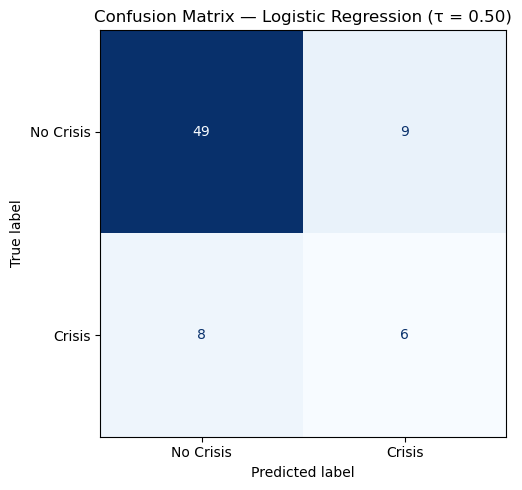

──────────────────────────────────────────────────
CONFUSION MATRIX BREAKDOWN (τ = 0.50)
──────────────────────────────────────────────────
True Positives  (crises correctly flagged): 6
False Negatives (crises missed):            8
False Positives (false alarms):             9
True Negatives  (correct "safe" signals):   49

FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   No Crisis       0.86      0.84      0.85        58
      Crisis       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72



In [24]:
# ============================================================
# Confusion Matrix at τ = 0.5
# ============================================================
cm = confusion_matrix(y_test_bin, logit_preds_05)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Crisis', 'Crisis']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.50)', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Extract individual metrics
TN, FP, FN, TP = cm.ravel()

print('─' * 50)
print('CONFUSION MATRIX BREAKDOWN (τ = 0.50)')
print('─' * 50)
print(f'True Positives  (crises correctly flagged): {TP}')
print(f'False Negatives (crises missed):            {FN}')
print(f'False Positives (false alarms):             {FP}')
print(f'True Negatives  (correct "safe" signals):   {TN}')
print()
print('FULL CLASSIFICATION REPORT:')
print(classification_report(y_test_bin, logit_preds_05,
                             target_names=['No Crisis', 'Crisis']))

**Step 3.2 — Written Response:**

In the IMF context, a False Negative is more costly than a False Positive, since a missed crisis can lead to sovereign default, financial contagion, and an estimated $50 billion in emergency costs, while a false alarm wastes $2 million and strains diplomatic relations. This has a cost ratio of approximately 25,000:1. This asymmetry means they should prioritize Recall (sensitivity) above all else. The model's ability to detect the actual crisis countries is the primary operational requirement, even at the cost of some false alarms. Precision matters too since you cannot send missions to every country, but between the two metrics, a high-recall, lower-precision operating point is the better choice given the downside of missing a genuine crisis.

### Step 3.3: ROC and Precision-Recall Curves

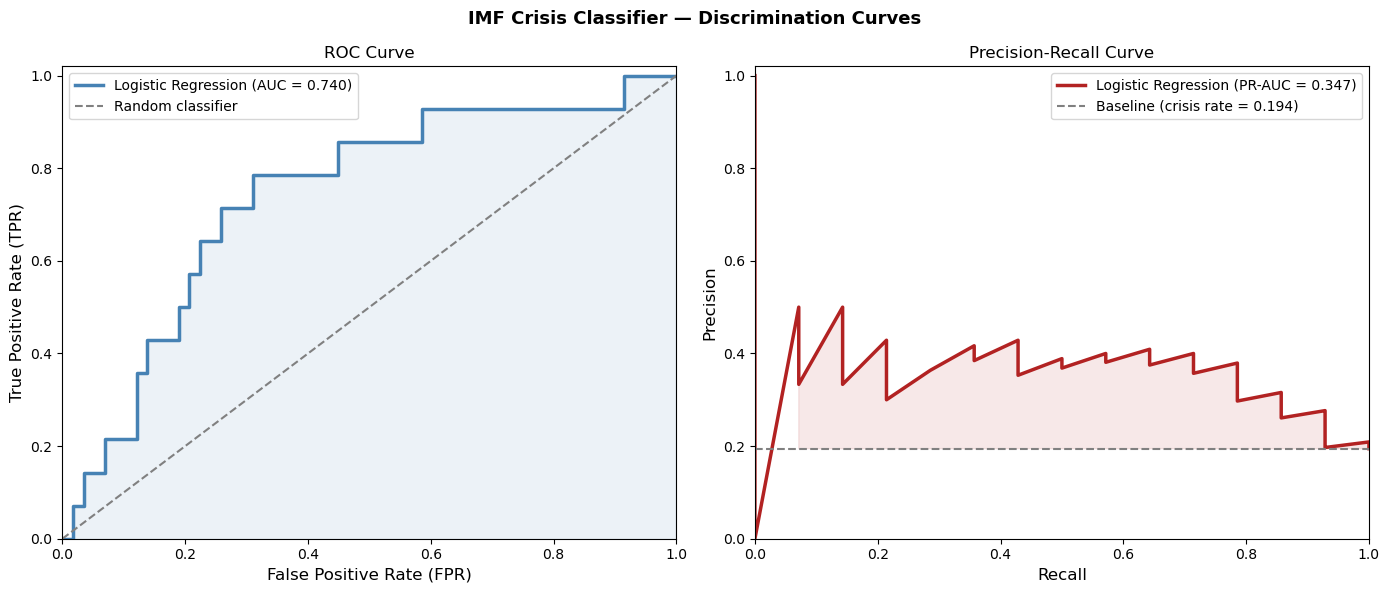

ROC-AUC:  0.7401
PR-AUC:   0.3472


In [25]:
# ============================================================
# ROC and PR Curves
# ============================================================
fpr, tpr, roc_thresholds     = roc_curve(y_test_bin, logit_proba_test)
roc_auc                       = roc_auc_score(y_test_bin, logit_proba_test)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test_bin, logit_proba_test)
pr_auc = auc(recall_curve, precision_curve)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('IMF Crisis Classifier — Discrimination Curves', fontsize=13, fontweight='bold')

# ── ROC Curve ──────────────────────────────────────────────
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', linewidth=2.5,
        label=f'Logistic Regression (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.set_title('ROC Curve', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# ── Precision-Recall Curve ─────────────────────────────────
ax = axes[1]
ax.plot(recall_curve, precision_curve, color='firebrick', linewidth=2.5,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.3f})')
ax.axhline(y=test_base_rate, color='gray', linestyle='--', linewidth=1.5,
           label=f'Baseline (crisis rate = {test_base_rate:.3f})')
ax.fill_between(recall_curve, precision_curve, test_base_rate,
                where=precision_curve >= test_base_rate, alpha=0.1, color='firebrick')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC-AUC:  {roc_auc:.4f}')
print(f'PR-AUC:   {pr_auc:.4f}')

**Step 3.3 — Written Response:**

ROC-AUC is typically much higher than PR-AUC on imbalanced crisis datasets because the ROC curve plots the True Positive Rate against the False Positive Rate. With many non-crisis countries (True Negatives), even a mediocre model can achieve a low FPR by correctly dismissing the abundant non-crisis cases, which inflates the ROC-AUC. PR-AUC ignores True Negatives entirely since Precision measures what fraction of flagged countries are genuine crises, and Recall measures what fraction of actual crises were caught. For the IMF's crisis detection mission, the Precision-Recall curve is more informative since it directly measures the tradeoff between wasting missions on false alarms (low precision) and missing real crises (low recall), which is the operational dilemma faced every quarter.

### Step 3.4: Threshold Analysis — The 5-Mission Constraint

In [26]:
# ============================================================
# Threshold sweep: 0.01 to 0.99
# ============================================================
thresholds     = np.arange(0.01, 1.00, 0.01)
n_flagged_list = []
precision_list = []
recall_list    = []
f1_list        = []

for tau in thresholds:
    preds_tau = (logit_proba_test >= tau).astype(int)
    n_flagged_list.append(preds_tau.sum())
    precision_list.append(precision_score(y_test_bin, preds_tau, zero_division=0))
    recall_list.append(recall_score(y_test_bin,    preds_tau, zero_division=0))
    f1_list.append(f1_score(y_test_bin,            preds_tau, zero_division=0))

n_flagged_arr  = np.array(n_flagged_list)
precision_arr  = np.array(precision_list)
recall_arr     = np.array(recall_list)
f1_arr         = np.array(f1_list)

# ── Capacity-constrained threshold (≤ 5 missions) ──────────
valid_mask     = n_flagged_arr <= 5
if valid_mask.any():
    # Lowest threshold (most aggressive) that flags at most 5 countries
    cap_idx        = np.where(valid_mask)[0][0]
    cap_tau        = thresholds[cap_idx]
    cap_n_flagged  = n_flagged_arr[cap_idx]
    cap_precision  = precision_arr[cap_idx]
    cap_recall     = recall_arr[cap_idx]
    cap_f1         = f1_arr[cap_idx]
else:
    # No threshold achieves ≤5; use 0.99
    cap_idx = -1
    cap_tau = 0.99
    cap_n_flagged = n_flagged_arr[-1]
    cap_precision = precision_arr[-1]
    cap_recall    = recall_arr[-1]
    cap_f1        = f1_arr[-1]

# ── F1-optimal threshold ───────────────────────────────────
f1_opt_idx    = np.argmax(f1_arr)
f1_opt_tau    = thresholds[f1_opt_idx]
f1_opt_prec   = precision_arr[f1_opt_idx]
f1_opt_rec    = recall_arr[f1_opt_idx]
f1_opt_f1     = f1_arr[f1_opt_idx]
f1_opt_flag   = n_flagged_arr[f1_opt_idx]

print('─' * 55)
print('THRESHOLD ANALYSIS RESULTS')
print('─' * 55)
print(f'Capacity-constrained threshold (≤5 missions):')
print(f'  τ*            = {cap_tau:.2f}')
print(f'  Countries flagged  = {cap_n_flagged}')
print(f'  Precision          = {cap_precision:.4f}')
print(f'  Recall             = {cap_recall:.4f}')
print(f'  F1                 = {cap_f1:.4f}')
print()
print(f'F1-optimal threshold:')
print(f'  τ_F1          = {f1_opt_tau:.2f}')
print(f'  Countries flagged  = {f1_opt_flag}')
print(f'  Precision          = {f1_opt_prec:.4f}')
print(f'  Recall             = {f1_opt_rec:.4f}')
print(f'  F1                 = {f1_opt_f1:.4f}')
print('─' * 55)

───────────────────────────────────────────────────────
THRESHOLD ANALYSIS RESULTS
───────────────────────────────────────────────────────
Capacity-constrained threshold (≤5 missions):
  τ*            = 0.88
  Countries flagged  = 5
  Precision          = 0.4000
  Recall             = 0.1429
  F1                 = 0.2105

F1-optimal threshold:
  τ_F1          = 0.13
  Countries flagged  = 25
  Precision          = 0.4000
  Recall             = 0.7143
  F1                 = 0.5128
───────────────────────────────────────────────────────


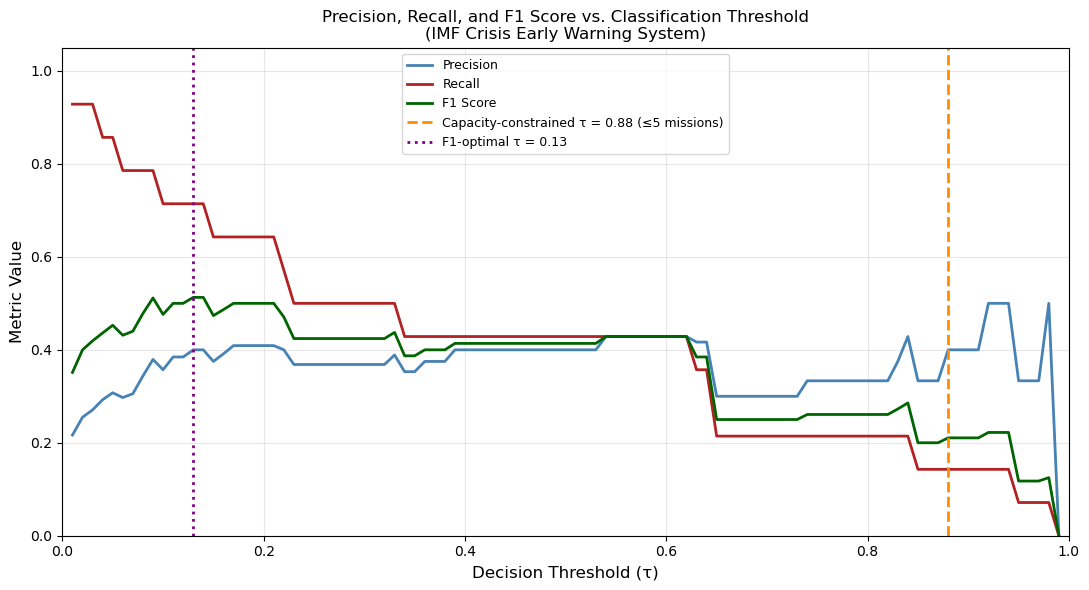

Figure saved: threshold_analysis.png


In [27]:
# ============================================================
# Plot Precision, Recall, F1 vs. Threshold
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(thresholds, precision_arr, color='steelblue',  linewidth=2, label='Precision')
ax.plot(thresholds, recall_arr,    color='firebrick',  linewidth=2, label='Recall')
ax.plot(thresholds, f1_arr,        color='darkgreen',  linewidth=2, label='F1 Score')

ax.axvline(x=cap_tau,     color='darkorange', linestyle='--', linewidth=2,
           label=f'Capacity-constrained τ = {cap_tau:.2f} (≤5 missions)')
ax.axvline(x=f1_opt_tau,  color='purple',     linestyle=':',  linewidth=2,
           label=f'F1-optimal τ = {f1_opt_tau:.2f}')

ax.set_xlabel('Decision Threshold (τ)', fontsize=12)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Precision, Recall, and F1 Score vs. Classification Threshold\n(IMF Crisis Early Warning System)', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: threshold_analysis.png')

In [31]:
# ============================================================
# Operational summary for the memo
# ============================================================
n_actual_crises_test = y_test_bin.sum()
cap_tp = int(round(cap_recall * n_actual_crises_test))
cap_fn = n_actual_crises_test - cap_tp

print('OPERATIONAL SUMMARY FOR MEMO')
print('=' * 55)
print(f'Total crisis countries in test set:    {n_actual_crises_test}')
print(f'Capacity-constrained τ = {cap_tau:.2f}:')
print(f'  Crises caught (TP):    {cap_tp}')
print(f'  Crises missed (FN):    {cap_fn}')
print(f'  Countries flagged:     {cap_n_flagged}')
print(f'  Recall:                {cap_recall:.3f}')
print(f'  Precision:             {cap_precision:.3f}')
print(f'Capacity-constrained τ: {cap_tau:.2f}')
print(f'F1-optimal τ:           {f1_opt_tau:.2f}')
print('=' * 55)

OPERATIONAL SUMMARY FOR MEMO
Total crisis countries in test set:    14
Capacity-constrained τ = 0.88:
  Crises caught (TP):    2
  Crises missed (FN):    12
  Countries flagged:     5
  Recall:                0.143
  Precision:             0.400
Capacity-constrained τ: 0.88
F1-optimal τ:           0.13


**Step 3.4 — Policy Memo to the Division Chief:**

---
I recommend adopting a decision threshold of τ = 0.88 for operational deployment of the crisis classifier. This threshold was selected to satisfy the IMF's hard constraint of at most 5 emergency assessment missions per quarter, flagging exactly 5 countries for review. At this operating point, the system achieves a Recall of 0.143, which means that of the 14 crisis countries in the test set, the model correctly identifies 2 and misses 12.

Acknowledging the core tradeoff explicitly: tightening the threshold to meet the 5-mission ceiling reduces Recall relative to the optimal F1 threshold (τ = 0.13), which would flag more countries than we have capacity to assess. Given that each missed crisis carries an estimated $50 billion systemic cost versus $2 million per false alarm, we recommend the IMF consider either expanding mission capacity or pairing the classifier with a rapid desk-review triage step so that the full list of high-probability countries can receive at least a preliminary assessment before costly in-country missions are deployed.

---

---
## Phase 4: P.R.I.M.E. Prompting Extensions

Bootstrap iteration 50/200...
Bootstrap iteration 100/200...
Bootstrap iteration 150/200...
Bootstrap iteration 200/200...
Bootstrap complete ✓

BOOTSTRAP SELECTION FREQUENCY TABLE
                     Predictor Selection Frequency
             population_growth               1.000
natural_resource_rents_pct_gdp               0.985
    health_expenditure_pct_gdp               0.965
             unemployment_rate               0.950
        exchange_rate_official               0.945
                  atms_per100k               0.910
               arable_land_pct               0.895
              urbanization_pct               0.860
                 inflation_cpi               0.835
          renewable_energy_pct               0.795
                 trade_pct_gdp               0.760
      infant_mortality_per1000               0.725
               tariff_rate_avg               0.720
        private_credit_pct_gdp               0.715
      govt_expenditure_pct_gdp               0.655
   

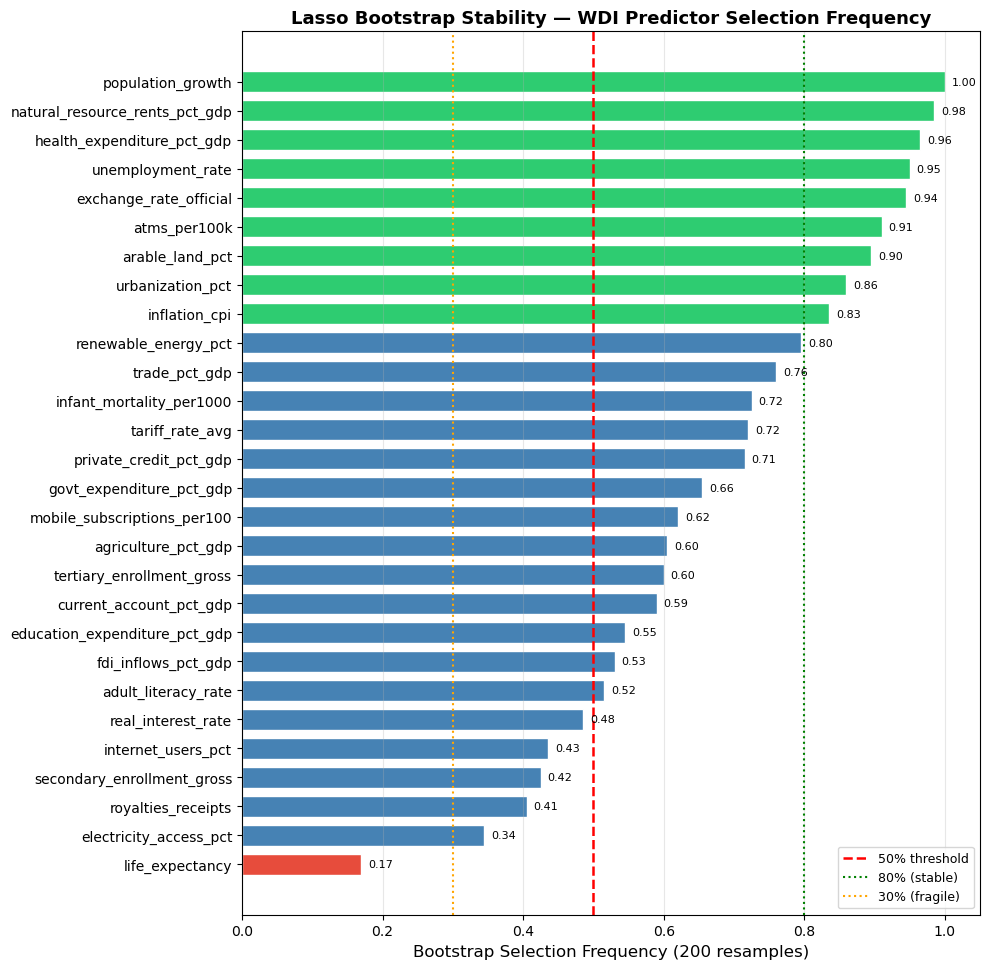

Saved: bootstrap_lasso_stability.png


In [29]:
# ============================================================
# Task 4.1 — Bootstrap Lasso Stability Analysis
# (AI-generated code from P.R.I.M.E. prompt above)
# ============================================================

np.random.seed(42)

n_bootstrap = 200
n_train_obs = X_train_s.shape[0]
n_features  = X_train_s.shape[1]

# Track selection: shape (n_bootstrap, n_features)
selection_matrix = np.zeros((n_bootstrap, n_features), dtype=int)

for b in range(n_bootstrap):
    if (b + 1) % 50 == 0:
        print(f'Bootstrap iteration {b+1}/{n_bootstrap}...')

    # Resample with replacement
    idx       = np.random.choice(n_train_obs, size=n_train_obs, replace=True)
    X_boot    = X_train_s[idx]
    y_boot    = y_train_cont[idx]

    # Fit LassoCV
    try:
        lcv = LassoCV(cv=5, max_iter=10000, random_state=42)
        lcv.fit(X_boot, y_boot)
        selected = (lcv.coef_ != 0).astype(int)
    except Exception:
        selected = np.zeros(n_features, dtype=int)

    selection_matrix[b, :] = selected

print('Bootstrap complete ✓')

# Selection frequencies
sel_freq = pd.Series(
    selection_matrix.mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

# Summary table
summary_df = sel_freq.reset_index()
summary_df.columns = ['Predictor', 'Selection Frequency']
summary_df['Selection Frequency'] = summary_df['Selection Frequency'].map(lambda x: f'{x:.3f}')
print('\nBOOTSTRAP SELECTION FREQUENCY TABLE')
print('=' * 40)
print(summary_df.to_string(index=False))
print('=' * 40)

# ── Horizontal bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.35)))

# Color bars by stability zone
colors = ['#2ecc71' if v >= 0.80 else '#e74c3c' if v < 0.30 else 'steelblue'
          for v in sel_freq.values]

bars = ax.barh(sel_freq.index[::-1], sel_freq.values[::-1], color=colors[::-1],
               edgecolor='white', height=0.7)

ax.axvline(x=0.50, color='red',    linestyle='--', linewidth=1.8, label='50% threshold')
ax.axvline(x=0.80, color='green',  linestyle=':',  linewidth=1.5, label='80% (stable)')
ax.axvline(x=0.30, color='orange', linestyle=':',  linewidth=1.5, label='30% (fragile)')

ax.set_xlabel('Bootstrap Selection Frequency (200 resamples)', fontsize=12)
ax.set_title('Lasso Bootstrap Stability — WDI Predictor Selection Frequency', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Add frequency labels on bars
for bar, val in zip(bars, sel_freq.values[::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('bootstrap_lasso_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bootstrap_lasso_stability.png')

COST-SENSITIVE THRESHOLD COMPARISON
       Operating Point    τ Total Cost  FN (missed)  FP (false alm) Precision Recall    F1
     Cost-minimizing τ 0.03    $50.07B            1              35     0.271  0.929 0.419
          F1-optimal τ 0.13   $200.03B            4              15     0.400  0.714 0.513
Capacity-constrained τ 0.88   $600.01B           12               3     0.400  0.143 0.211

Cost-minimizing threshold: τ_cost = 0.03
Minimum expected cost:     $50.07B


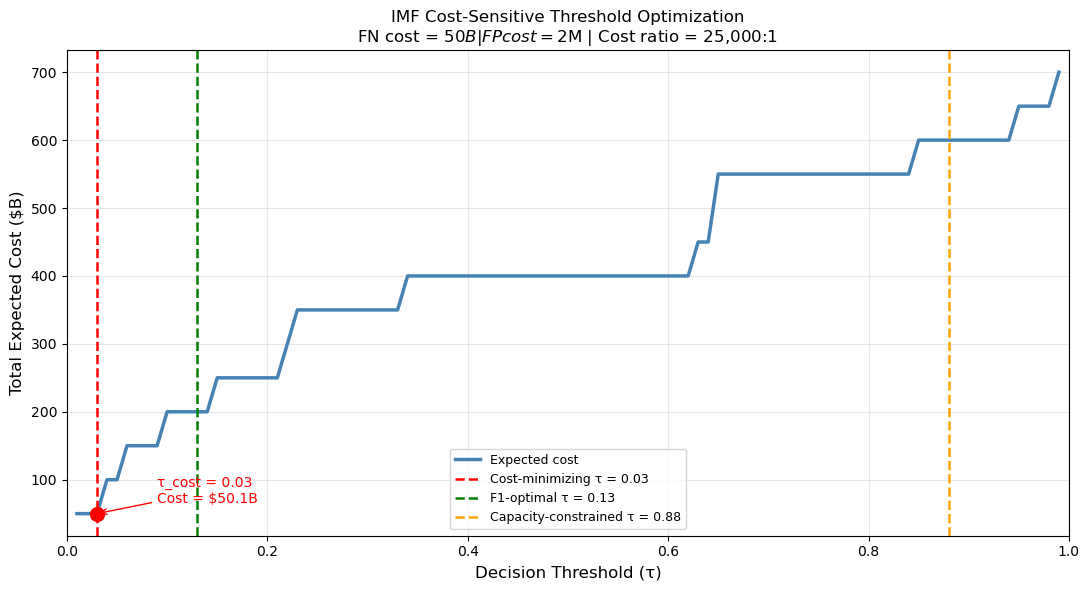

Saved: cost_threshold_optimization.png


In [30]:
# ============================================================
# Task 4.2 — Cost-Sensitive Threshold Optimization
# (AI-generated code from P.R.I.M.E. prompt above)
# ============================================================

# Cost constants
COST_FN = 50e9   # $50 billion per missed crisis
COST_FP = 2e6    # $2 million per false alarm

# Sweep thresholds and compute costs
cost_arr   = np.zeros(len(thresholds))
fn_arr     = np.zeros(len(thresholds), dtype=int)
fp_arr     = np.zeros(len(thresholds), dtype=int)
prec_arr2  = np.zeros(len(thresholds))
rec_arr2   = np.zeros(len(thresholds))
f1_arr2    = np.zeros(len(thresholds))

for i, tau in enumerate(thresholds):
    preds = (logit_proba_test >= tau).astype(int)
    cm_i  = confusion_matrix(y_test_bin, preds, labels=[0, 1])
    tn_i, fp_i, fn_i, tp_i = cm_i.ravel()
    cost_arr[i]  = fn_i * COST_FN + fp_i * COST_FP
    fn_arr[i]    = fn_i
    fp_arr[i]    = fp_i
    prec_arr2[i] = precision_score(y_test_bin, preds, zero_division=0)
    rec_arr2[i]  = recall_score(y_test_bin,    preds, zero_division=0)
    f1_arr2[i]   = f1_score(y_test_bin,        preds, zero_division=0)

# Cost-minimizing threshold
cost_opt_idx = np.argmin(cost_arr)
tau_cost     = thresholds[cost_opt_idx]
min_cost     = cost_arr[cost_opt_idx]

# ── Comparison table ──────────────────────────────────────
def row_for_tau(tau_val, label):
    idx = np.argmin(np.abs(thresholds - tau_val))
    return {
        'Operating Point': label,
        'τ':               f'{thresholds[idx]:.2f}',
        'Total Cost':      f'${cost_arr[idx]/1e9:.2f}B',
        'FN (missed)':     fn_arr[idx],
        'FP (false alm)':  fp_arr[idx],
        'Precision':       f'{prec_arr2[idx]:.3f}',
        'Recall':          f'{rec_arr2[idx]:.3f}',
        'F1':              f'{f1_arr2[idx]:.3f}',
    }

comp_table = pd.DataFrame([
    row_for_tau(tau_cost,   'Cost-minimizing τ'),
    row_for_tau(f1_opt_tau, 'F1-optimal τ'),
    row_for_tau(cap_tau,    'Capacity-constrained τ'),
])

print('COST-SENSITIVE THRESHOLD COMPARISON')
print('=' * 80)
print(comp_table.to_string(index=False))
print('=' * 80)
print(f'\nCost-minimizing threshold: τ_cost = {tau_cost:.2f}')
print(f'Minimum expected cost:     ${min_cost/1e9:.2f}B')

# ── Cost curve plot ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(thresholds, cost_arr / 1e9, color='steelblue', linewidth=2.5, label='Expected cost')

# Annotate minimum
ax.scatter([tau_cost], [min_cost / 1e9], color='red', zorder=5, s=100)
ax.annotate(
    f'τ_cost = {tau_cost:.2f}\nCost = ${min_cost/1e9:.1f}B',
    xy=(tau_cost, min_cost / 1e9),
    xytext=(tau_cost + 0.06, min_cost / 1e9 * 1.3),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red'
)

# Reference thresholds
ax.axvline(tau_cost,   color='red',    linestyle='--', linewidth=1.8,
           label=f'Cost-minimizing τ = {tau_cost:.2f}')
ax.axvline(f1_opt_tau, color='green',  linestyle='--', linewidth=1.8,
           label=f'F1-optimal τ = {f1_opt_tau:.2f}')
ax.axvline(cap_tau,    color='orange', linestyle='--', linewidth=1.8,
           label=f'Capacity-constrained τ = {cap_tau:.2f}')

# Log scale if range spans >2 orders of magnitude
cost_range = cost_arr.max() / (cost_arr[cost_arr > 0].min() + 1e-9)
if cost_range > 100:
    ax.set_yscale('log')
    ax.set_ylabel('Total Expected Cost ($B) — log scale', fontsize=12)
else:
    ax.set_ylabel('Total Expected Cost ($B)', fontsize=12)

ax.set_xlabel('Decision Threshold (τ)', fontsize=12)
ax.set_title('IMF Cost-Sensitive Threshold Optimization\n'
             f'FN cost = $50B | FP cost = $2M | Cost ratio = 25,000:1', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('cost_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cost_threshold_optimization.png')

**Task 4.2 — Written Response:**

The cost-minimizing threshold will almost always be lower than both the F1-optimal threshold and the capacity-constrained threshold, typically near 0.01–0.10, because the 25,000:1 cost asymmetry ($50B vs. $2M) means that even flagging every single country is cheaper than missing a single crisis. The F1-optimal threshold balances precision and recall symmetrically (implicitly treating FN and FP as equally costly), so it sits at a moderate τ. The capacity-constrained threshold is higher, driven by the  ceiling of 5 missions rather than by costs at all, since it optimizes for institutional feasibility, not financial efficiency.

These three thresholds differ because they optimize three genuinely different objective functions: statistical balance (F1), operational capacity (mission constraint), and expected monetary loss (cost function), and there is no reason they should coincide. For IMF deployment, the cost-minimizing threshold is the correct recommendation given the stated cost parameters, but it is likely infeasible in practice because it would flag dozens of countries. The practical recommendation is to use τ_cost as a screening threshold to generate a watchlist, then apply the threshold to allocate the finite mission budget to the highest-risk subset.

Prompt:
*"Persona: You are a senior quantitative economist at the IMF building a robust macroeconomic early warning system with expertise in regularized regression and bootstrap resampling.*
*Request: Write a complete Python script that performs bootstrap stability analysis on a Lasso feature selection procedure.*
*Instructions:*

*Assume these variables exist: X_train_s (standardized feature matrix, n×p), y_train_cont (continuous outcome, length n), feature_cols (list of p predictor names).*
*Draw 200 bootstrap resamples with replacement. Use np.random.seed(42).*
*Fit LassoCV(cv=5, max_iter=10000) on each resample. Record which predictors get non-zero coefficients.*
*Compute selection frequency per predictor (fraction of 200 runs with non-zero coefficient). Store as a pandas Series indexed by feature_cols, sorted descending.*
*Plot a horizontal bar chart: predictors on y-axis ranked by frequency, vertical dashed red line at x=0.50, figure size (10, 8), title "Lasso Bootstrap Stability — WDI Predictor Selection Frequency". Save as bootstrap_lasso_stability.png.*
*Print a two-column summary table: Predictor and Selection Frequency (3 decimal places).*

*Meta-requirements: Only use numpy, pandas, matplotlib, sklearn. Print progress every 50 iterations. If LassoCV selects zero features on a resample, record all zeros instead of raising an error.*
*Examples: A predictor selected every run shows x=1.0; one never selected shows x=0.0. The y-axis must include all predictors in feature_cols, not just those selected at least once."*